### ReAct Agent Architecture

#### Aim
This is the intuition behind ReAct, a general agent architecture.

1. act - let the model call specific tools
2. observe - pass the tool output back to the model
3. reason - let the model reason about the tool output to decide what to do next (e.g., call another tool or just respond directly)

<div style="text-align:center">
  <img src="../assets/react_langgraph.png">
</div>


In [1]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper,ArxivAPIWrapper

In [2]:
api_wrapper_wiki = WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=500)
wiki_tool = WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
api_wrapper_arxiv = ArxivAPIWrapper(max_results=2,doc_content_chars_max=500)
arxiv_tool = ArxivQueryRun(api_wrapper=api_wrapper_arxiv)

In [3]:
from dotenv import load_dotenv
load_dotenv()
import os
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["LANGCHAIN_API_KEY"]=os.getenv("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT"]="ReAct-agent"

In [4]:
### Custom Functions
def multiply(a: int, b: int) -> int:
    """Multiply a and b.

    Args:
        a: first int
        b: second int
    """
    return a * b

# This will be a tool
def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b

In [5]:
tools=[arxiv_tool,wiki_tool,add,multiply,divide]

In [6]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model_name="gpt-4")

llm_with_tools = llm.bind_tools(tools)

/home/aniruddha/Projects/RAG/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
from langgraph.graph.message import add_messages, AnyMessage
from typing import Annotated
from pydantic import BaseModel

class state(BaseModel):
    messages: Annotated[list[AnyMessage],add_messages]

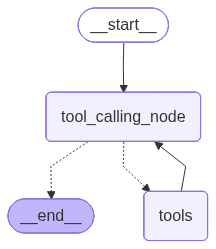

In [11]:
### Entire Chatbot With LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

# Node definition
def tool_calling_node(state:state):
    return {"messages": [llm_with_tools.invoke(state.messages)]}

# Build graph

builder = StateGraph(state)
builder.add_node("tool_calling_node", tool_calling_node)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_node")
# If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
# If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
builder.add_conditional_edges(
    "tool_calling_node",
    tools_condition
)

builder.add_edge("tools","tool_calling_node")

graph_builder = builder.compile()

# View
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [12]:
from langchain_core.messages import AIMessage, HumanMessage
messages=graph_builder.invoke({"messages":HumanMessage(content="What is machine learning")})
print(messages)
for m in messages['messages']:
    m.pretty_print()

{'messages': [HumanMessage(content='What is machine learning', additional_kwargs={}, response_metadata={}, id='23131dd9-b96e-4b91-97eb-8421ed5f699d'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 258, 'total_tokens': 273, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4-0613', 'system_fingerprint': None, 'id': 'chatcmpl-D11PF1mBsZDePhZJ7NXqS8jPQZS3Y', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019be8ba-a651-76e3-9b92-3a4c9f9ded82-0', tool_calls=[{'name': 'wikipedia', 'args': {'query': 'Machine learning'}, 'id': 'call_J1e4RApAKWvTXY0hYl3OqJ0g', 'type': 'tool_call'}], usage_metadata={'input_tokens': 258, 'output_tokens': 15, 'total_tokens': 273, 'inpu

### Agent Memory
#### Aim
Lets introduce Agent With Memory

In [14]:
messages=graph_builder.invoke({"messages":HumanMessage(content="What is 5 plus 8")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 plus 8
================================== Ai Message ==================================
Tool Calls:
  add (call_j4hWC3bSedGIsqR6KVQgqnya)
 Call ID: call_j4hWC3bSedGIsqR6KVQgqnya
  Args:
    a: 5
    b: 8
================================= Tool Message =================================
Name: add

13
================================== Ai Message ==================================

5 plus 8 equals 13.


In [15]:
messages=[HumanMessage(content="Divide that by 5")]
messages=graph_builder.invoke({"messages":messages})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Divide that by 5
================================== Ai Message ==================================

I'm sorry, but I need you to provide two numbers for the operation. Could you please provide the number you would like to divide by 5?


#### MemorySaver
LangGraph can use a checkpointer to automatically save the graph state after each step.

This built-in persistence layer gives us memory, allowing LangGraph to pick up from the last state update.

One of the easiest checkpointers to use is the MemorySaver, an in-memory key-value store for Graph state.

All we need to do is simply compile the graph with a checkpointer, and our graph has memory!

<div style="text-align:center">
  <img src="../assets/react_memory.png">
</div>

In [ ]:
llm_4o = ChatOpenAI(model_name="gpt-4o")

llm_with_tools_4o = llm_4o.bind_tools(tools)

In [ ]:
### Entire Chatbot With LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

# Node definition
def tool_calling_node(state:state):
    return {"messages": [llm_with_tools.invoke(state.messages)]}

# Build graph

builder = StateGraph(state)
builder.add_node("tool_calling_node", tool_calling_node)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_node")
# If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
# If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
builder.add_conditional_edges(
    "tool_calling_node",
    tools_condition
)

builder.add_edge("tools","tool_calling_node")


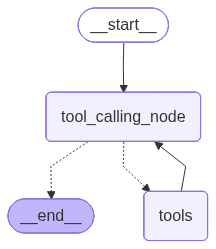

In [16]:
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

graph_memory = builder.compile(checkpointer=memory)

display(Image(graph_memory.get_graph().draw_mermaid_png()))

In [17]:
## Specify the thread

config = {"configurable":{"thread_id":"1"}}

# Specify an input
input = [HumanMessage(content="What is 10 + 5?")]

messages=graph_memory.invoke({"messages":input},config=config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 10 + 5?
================================== Ai Message ==================================
Tool Calls:
  add (call_twSvDqPG7vk5M7N1XUkweOt5)
 Call ID: call_twSvDqPG7vk5M7N1XUkweOt5
  Args:
    a: 10
    b: 5
================================= Tool Message =================================
Name: add

15
================================== Ai Message ==================================

10 + 5 equals 15.


In [ ]:
input = [HumanMessage(content="Add 16 to number")]

messages=graph_memory.invoke({"messages":input},config=config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 10 + 5?
================================== Ai Message ==================================
Tool Calls:
  add (call_twSvDqPG7vk5M7N1XUkweOt5)
 Call ID: call_twSvDqPG7vk5M7N1XUkweOt5
  Args:
    a: 10
    b: 5
================================= Tool Message =================================
Name: add

15
================================== Ai Message ==================================

10 + 5 equals 15.
================================ Human Message =================================

Add 16 to number
================================== Ai Message ==================================
Tool Calls:
  add (call_2qqrzOLk7UphNTXZ4LqcxYHo)
 Call ID: call_2qqrzOLk7UphNTXZ4LqcxYHo
  Args:
    a: 15
    b: 16
================================= Tool Message =================================
Name: add

31
================================== Ai Message ==================================

15 + 16 equals 31.


In [19]:
input = [HumanMessage(content="multiply 8 to number, after that divide by 4")]

messages=graph_memory.invoke({"messages":input},config=config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 10 + 5?
================================== Ai Message ==================================
Tool Calls:
  add (call_twSvDqPG7vk5M7N1XUkweOt5)
 Call ID: call_twSvDqPG7vk5M7N1XUkweOt5
  Args:
    a: 10
    b: 5
================================= Tool Message =================================
Name: add

15
================================== Ai Message ==================================

10 + 5 equals 15.
================================ Human Message =================================

Add 16 to number
================================== Ai Message ==================================
Tool Calls:
  add (call_2qqrzOLk7UphNTXZ4LqcxYHo)
 Call ID: call_2qqrzOLk7UphNTXZ4LqcxYHo
  Args:
    a: 15
    b: 16
================================= Tool Message =================================
Name: add

31
================================== Ai Message ==================================

15 + 16 equals 31.
===============

In [20]:
input = [HumanMessage(content="what 4 multiplied by 9")]

messages=graph_memory.invoke({"messages":input},config=config)
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 10 + 5?
================================== Ai Message ==================================
Tool Calls:
  add (call_twSvDqPG7vk5M7N1XUkweOt5)
 Call ID: call_twSvDqPG7vk5M7N1XUkweOt5
  Args:
    a: 10
    b: 5
================================= Tool Message =================================
Name: add

15
================================== Ai Message ==================================

10 + 5 equals 15.
================================ Human Message =================================

Add 16 to number
================================== Ai Message ==================================
Tool Calls:
  add (call_2qqrzOLk7UphNTXZ4LqcxYHo)
 Call ID: call_2qqrzOLk7UphNTXZ4LqcxYHo
  Args:
    a: 15
    b: 16
================================= Tool Message =================================
Name: add

31
================================== Ai Message ==================================

15 + 16 equals 31.
===============